# 01 Dataset Exploration: Oxford-IIIT Pet Dataset

This notebook begins the Advanced Computer Vision group project on pet breed classification and visual similarity search.

The project uses the Oxford-IIIT Pet Dataset, a public computer vision dataset containing images of cats and dogs across 37 breed categories. The project has two core tasks:

1. **Pet Breed Classification**: predict the breed category from an input image.
2. **Similarity-Based Image Retrieval**: use CNN feature embeddings to retrieve visually similar pet images.

The purpose of this notebook is to inspect the dataset, verify the class labels, visualize sample images, evaluate class distribution, and establish preprocessing decisions that will be used consistently in later modeling notebooks.

## 1. Imports and Configuration

This section imports the main Python libraries used for dataset loading, tabular summaries, visualization, and reproducibility.

We use TensorFlow Datasets to load the Oxford-IIIT Pet Dataset directly. This keeps the dataset loading process reproducible and avoids manually downloading and organizing image folders.

In [2]:
# Standard library imports
import os
import random
from pathlib import Path

# Core data science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow imports
import tensorflow as tf
import tensorflow_datasets as tfds

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Project constants
# Reasoning

# 224 x 224 works well with MobileNetV2, ResNet50, EfficientNetB0, and many standard pretrained CNNs.
# BATCH_SIZE = 32 is conventional and course-aligned.
# NUM_CLASSES = 37 matches the Oxford-IIIT Pets benchmark.
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 37

print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)

TensorFlow version: 2.19.1
TensorFlow Datasets version: 4.9.9


## 2. Project Directory Setup

The project uses a consistent folder structure so that figures, results, models, and embeddings are saved in predictable locations.

This notebook will save exploratory outputs into:

- `outputs/figures/`
- `outputs/results/`

In [3]:
# Determine project root.
# This assumes the notebook is located inside the notebooks/ folder.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULTS_DIR = OUTPUT_DIR / "results"
MODEL_DIR = OUTPUT_DIR / "models"
EMBEDDING_DIR = OUTPUT_DIR / "embeddings"

# Create directories if they do not already exist.
for directory in [DATA_DIR, OUTPUT_DIR, FIGURE_DIR, RESULTS_DIR, MODEL_DIR, EMBEDDING_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)
print("Results directory:", RESULTS_DIR)

Project root: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project
Figure directory: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/figures
Results directory: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results


## 3. Load the Oxford-IIIT Pet Dataset

The Oxford-IIIT Pet Dataset contains pet images labeled by breed. We load the official train and test splits using TensorFlow Datasets.

For this project, we use the full 37-class pet breed task. Although the project was initially discussed as dog breed classification, the dataset contains both dog and cat breeds. Therefore, we frame the task as **37-class pet breed classification**, consistent with the dataset and the TA's recommendation.

In [4]:

import certifi
print(certifi.where())

import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
print("SSL_CERT_FILE =", os.environ["SSL_CERT_FILE"])

/Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/venv/lib/python3.11/site-packages/certifi/cacert.pem
SSL_CERT_FILE = /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/venv/lib/python3.11/site-packages/certifi/cacert.pem


In [5]:
# # Load the Oxford-IIIT Pet Dataset from TensorFlow Datasets.
# # with_info=True gives us useful metadata such as label names and dataset size.
#
# (ds_train, ds_test), ds_info = tfds.load(
#     "oxford_iiit_pet",
#     split=["train", "test"],
#     as_supervised=False,
#     with_info=True,
#     shuffle_files=False
# )
#
# print(ds_info)

In [7]:
# ------------------------------------------------------------
# Load the Oxford-IIIT Pet Dataset
# ------------------------------------------------------------
# The dataset has already been downloaded and prepared.
# Future calls to tfds.load should reuse the local TFDS cache.

(ds_train, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=False,
    with_info=True,
    shuffle_files=False
)

# Store the official split sizes in variables for later cells.
num_train = ds_info.splits["train"].num_examples
num_test = ds_info.splits["test"].num_examples
num_total = num_train + num_test

# Print only the most important dataset facts instead of the full ds_info object.
# This avoids excessive notebook output.
print("Dataset name:", ds_info.name)
print("Dataset version:", ds_info.version)
print("Train examples:", ds_info.splits["train"].num_examples)
print("Test examples:", ds_info.splits["test"].num_examples)
print(f"Total number of examples:    {num_train + num_test}")
print("Number of breed classes:", ds_info.features["label"].num_classes)
print("Number of species classes:", ds_info.features["species"].num_classes)

Dataset name: oxford_iiit_pet
Dataset version: 4.0.0
Train examples: 3680
Test examples: 3669
Total number of examples:    7349
Number of breed classes: 37
Number of species classes: 2


In [8]:
# Environment check
import sys
import tensorflow as tf
import tensorflow_datasets as tfds
import importlib_resources

print("Python executable:", sys.executable)
print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)
print("importlib_resources is installed.")

Python executable: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/venv/bin/python
TensorFlow version: 2.19.1
TensorFlow Datasets version: 4.9.9
importlib_resources is installed.


## 4. Inspect Dataset Metadata

Before building models, we inspect the dataset metadata, including:

- number of examples in each split,
- available feature fields,
- breed label names,
- species label names.

In [9]:
# ------------------------------------------------------------
# Inspect Dataset Feature Structure
# ------------------------------------------------------------
# This confirms which fields are available for each example.
# The important fields for our core project are:
# - image: the input image
# - label: the breed classification target
# - species: cat/dog label used for dataset understanding
# - file_name: useful metadata
# - segmentation_mask and head_bbox: possible future extensions

print("Available dataset features:")

for feature_name, feature_object in ds_info.features.items():
    print(f"- {feature_name}: {feature_object}")

Available dataset features:
- image: Image(shape=(None, None, 3), dtype=uint8)
- label: ClassLabel(shape=(), dtype=int64, num_classes=37)
- species: ClassLabel(shape=(), dtype=int64, num_classes=2)
- file_name: Text(shape=(), dtype=string)
- segmentation_mask: Image(shape=(None, None, 1), dtype=uint8)
- head_bbox: BBoxFeature(shape=(4,), dtype=float32)


In [10]:
#
# Extract Breed and Species Label Names
#

# TensorFlow Datasets stores human-readable class names in ds_info.
# These names will be used later for plots, summaries, predictions, and model interpretation.

breed_names = ds_info.features["label"].names
species_names = ds_info.features["species"].names

print(f"Number of breed classes: {len(breed_names)}")
print(f"Number of species classes: {len(species_names)}")

print("\nFirst 10 breed names:")
for i, breed in enumerate(breed_names[:10]):
    print(f"{i:2d}: {breed}")

print("\nSpecies names:")
for i, species in enumerate(species_names):
    print(f"{i}: {species}")

Number of breed classes: 37
Number of species classes: 2

First 10 breed names:
 0: Abyssinian
 1: american_bulldog
 2: american_pit_bull_terrier
 3: basset_hound
 4: beagle
 5: Bengal
 6: Birman
 7: Bombay
 8: boxer
 9: British_Shorthair

Species names:
0: Cat
1: Dog


## 5. Build a Clean Metadata Table

Next, we create a metadata table summarizing each image in the dataset. This table will be useful for class counts, species counts, and later project documentation.

The metadata table includes:

- split,
- file name,
- breed label index,
- breed label name,
- species label index,
- species name,
- image height,
- image width,
- number of channels.

In [11]:
#
# Build Metadata Function
#

def build_metadata_dataframe(dataset, split_name, breed_names, species_names):
    """
    Build a pandas DataFrame containing metadata for each image example.

    Parameters
    ----------
    dataset : tf.data.Dataset
        TensorFlow dataset split, such as the training or test split.

    split_name : str
        Name of the split, such as 'train' or 'test'.

    breed_names : list
        Human-readable breed class names from TensorFlow Datasets.

    species_names : list
        Human-readable species class names from TensorFlow Datasets.

    Returns
    -------
    pd.DataFrame
        Metadata table for the selected dataset split.
    """

    # Store one dictionary per image example.
    records = []

    # Convert TensorFlow examples to NumPy-friendly objects for inspection.
    for example in tfds.as_numpy(dataset):

        # Extract the image array.
        image = example["image"]

        # Extract the numeric breed and species labels.
        label_index = int(example["label"])
        species_index = int(example["species"])

        # Decode the file name from bytes to a regular Python string.
        file_name = example["file_name"]
        if isinstance(file_name, bytes):
            file_name = file_name.decode("utf-8")

        # Record the raw image dimensions.
        height, width, channels = image.shape

        # Add this image's metadata to the records list.
        records.append({
            "split": split_name,
            "file_name": file_name,
            "breed_label": label_index,
            "breed_name": breed_names[label_index],
            "species_label": species_index,
            "species_name": species_names[species_index],
            "height": height,
            "width": width,
            "channels": channels
        })

    # Convert the list of records into a pandas DataFrame.
    return pd.DataFrame(records)

In [12]:
#
# Create Metadata Table
#

# Build separate metadata tables for the train and test splits.
train_metadata = build_metadata_dataframe(
    dataset=ds_train,
    split_name="train",
    breed_names=breed_names,
    species_names=species_names
)

test_metadata = build_metadata_dataframe(
    dataset=ds_test,
    split_name="test",
    breed_names=breed_names,
    species_names=species_names
)

# Combine the train and test metadata into one project-level table.
metadata_df = pd.concat(
    [train_metadata, test_metadata],
    ignore_index=True
)

print("Metadata shape:", metadata_df.shape)

metadata_df.head()

2026-04-27 19:47:16.564785: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-04-27 19:47:17.244225: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Metadata shape: (7349, 9)


2026-04-27 19:47:17.867319: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,split,file_name,breed_label,breed_name,species_label,species_name,height,width,channels
0,train,Sphynx_158.jpg,33,Sphynx,0,Cat,500,500,3
1,train,english_cocker_spaniel_135.jpg,12,english_cocker_spaniel,1,Dog,313,500,3
2,train,British_Shorthair_181.jpg,9,British_Shorthair,0,Cat,500,333,3
3,train,Siamese_161.jpg,32,Siamese,0,Cat,375,500,3
4,train,Sphynx_178.jpg,33,Sphynx,0,Cat,500,333,3


In [13]:
#
# Save Metadata Table
#

# Save the metadata table so later notebooks can reuse it without rebuilding it.
metadata_path = RESULTS_DIR / "01_dataset_metadata.csv"

metadata_df.to_csv(metadata_path, index=False)

print(f"Saved metadata to: {metadata_path}")

Saved metadata to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/01_dataset_metadata.csv


## 6. Dataset Summary

This section summarizes the number of examples, number of classes, species distribution, and image dimensions.

In [14]:
#
# Create Dataset Summary
#

# Create a compact one-row summary of the dataset.
dataset_summary = {
    "num_train_examples": num_train,
    "num_test_examples": num_test,
    "total_examples": num_train + num_test,
    "num_breed_classes": len(breed_names),
    "num_species_classes": len(species_names),
    "min_image_height": metadata_df["height"].min(),
    "max_image_height": metadata_df["height"].max(),
    "mean_image_height": metadata_df["height"].mean(),
    "min_image_width": metadata_df["width"].min(),
    "max_image_width": metadata_df["width"].max(),
    "mean_image_width": metadata_df["width"].mean(),
    "unique_channel_counts": sorted(metadata_df["channels"].unique().tolist())
}

# Convert the dictionary to a DataFrame for easier display and saving.
summary_df = pd.DataFrame([dataset_summary])

summary_df

,num_train_examples,num_test_examples,total_examples,num_breed_classes,num_species_classes,min_image_height,max_image_height,mean_image_height,min_image_width,max_image_width,mean_image_width,unique_channel_counts
0,3680,3669,7349,37,2,103,2606,391.387264,114,3264,437.237447,[3]


In [15]:
#
# Save Dataset Summary
#

# Save the dataset summary for the final report and summary notebook.
summary_path = RESULTS_DIR / "01_dataset_summary.csv"

summary_df.to_csv(summary_path, index=False)

print(f"Saved dataset summary to: {summary_path}")

Saved dataset summary to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/01_dataset_summary.csv


## 7. Class Distribution

A strong classification project should begin by checking whether the classes are reasonably balanced. Severe class imbalance can affect model training and may require special handling.

Here, we inspect the number of images per breed across the full dataset and by split.

In [16]:
#
# Calculate Class Counts
#

# Count the number of images for each breed across the full dataset.
class_counts = (
    metadata_df
    .groupby(["breed_label", "breed_name"])
    .size()
    .reset_index(name="count")
    .sort_values("breed_label")
)

class_counts.head()

,breed_label,breed_name,count
0,0,Abyssinian,198
1,1,american_bulldog,200
2,2,american_pit_bull_terrier,200
3,3,basset_hound,200
4,4,beagle,200


In [17]:
#
# Save Class Counts
#

# Save class counts for later reporting.
class_counts_path = RESULTS_DIR / "01_class_counts.csv"

class_counts.to_csv(class_counts_path, index=False)

print(f"Saved class counts to: {class_counts_path}")

Saved class counts to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/01_class_counts.csv


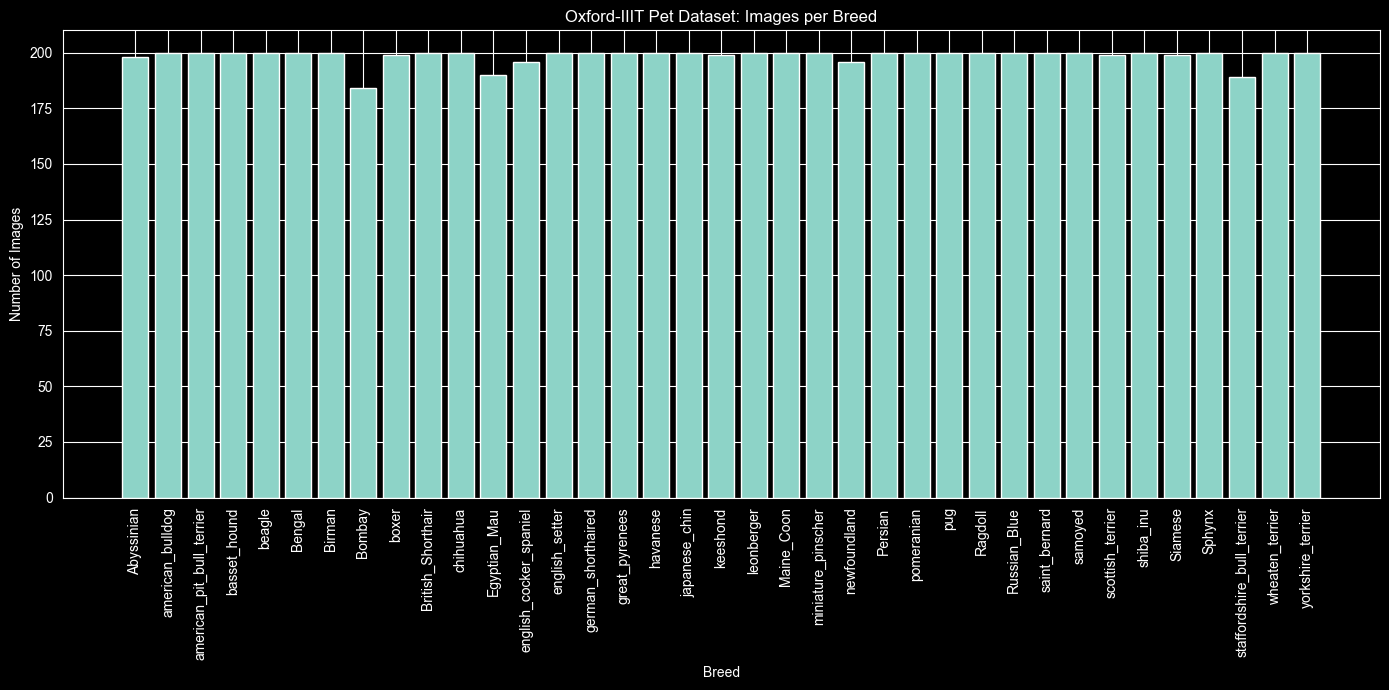

Saved class distribution plot to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/figures/01_class_distribution.png


In [18]:
#
# Plot Class Distribution
#

# Create a bar chart showing the number of images in each breed class.
plt.figure(figsize=(14, 7))

plt.bar(class_counts["breed_name"], class_counts["count"])

plt.xticks(rotation=90)
plt.xlabel("Breed")
plt.ylabel("Number of Images")
plt.title("Oxford-IIIT Pet Dataset: Images per Breed")

plt.tight_layout()

# Save the figure before displaying it.
class_distribution_path = FIGURE_DIR / "01_class_distribution.png"
plt.savefig(class_distribution_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved class distribution plot to: {class_distribution_path}")

## 8. Species Distribution

The dataset includes both cats and dogs. Although the main prediction target is breed, the species-level distribution helps us understand the broader composition of the dataset.

This also helps us explain why the project is best described as **pet breed classification** rather than dog-only breed classification.

In [19]:
#
# Calculate Species Counts
#

# Count the number of images for each species across the full dataset.
species_counts = (
    metadata_df
    .groupby(["species_label", "species_name"])
    .size()
    .reset_index(name="count")
    .sort_values("species_label")
)

species_counts

,species_label,species_name,count
0,0,Cat,2371
1,1,Dog,4978


In [20]:
#
# Save Species Counts
#

# Save species counts for later reporting.
species_counts_path = RESULTS_DIR / "01_species_counts.csv"

species_counts.to_csv(species_counts_path, index=False)

print(f"Saved species counts to: {species_counts_path}")

Saved species counts to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/results/01_species_counts.csv


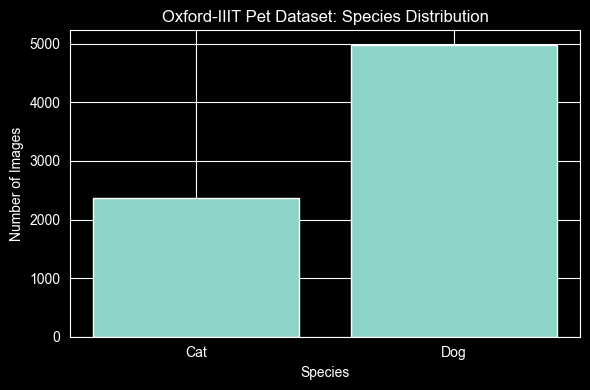

Saved species distribution plot to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/figures/01_species_distribution.png


In [21]:
#
# Plot Species Distribution
#

# Create a simple bar chart showing the number of cat and dog images.
plt.figure(figsize=(6, 4))

plt.bar(species_counts["species_name"], species_counts["count"])

plt.xlabel("Species")
plt.ylabel("Number of Images")
plt.title("Oxford-IIIT Pet Dataset: Species Distribution")

plt.tight_layout()

# Save the figure before displaying it.
species_distribution_path = FIGURE_DIR / "01_species_distribution.png"
plt.savefig(species_distribution_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved species distribution plot to: {species_distribution_path}")

## 9. Visualize Sample Images

Next, we display sample images from the training set. This helps us understand the visual variety in the data, including differences in pose, background, scale, lighting, color, and image quality.

This step is important because natural image variation is one reason transfer learning is useful for this project.

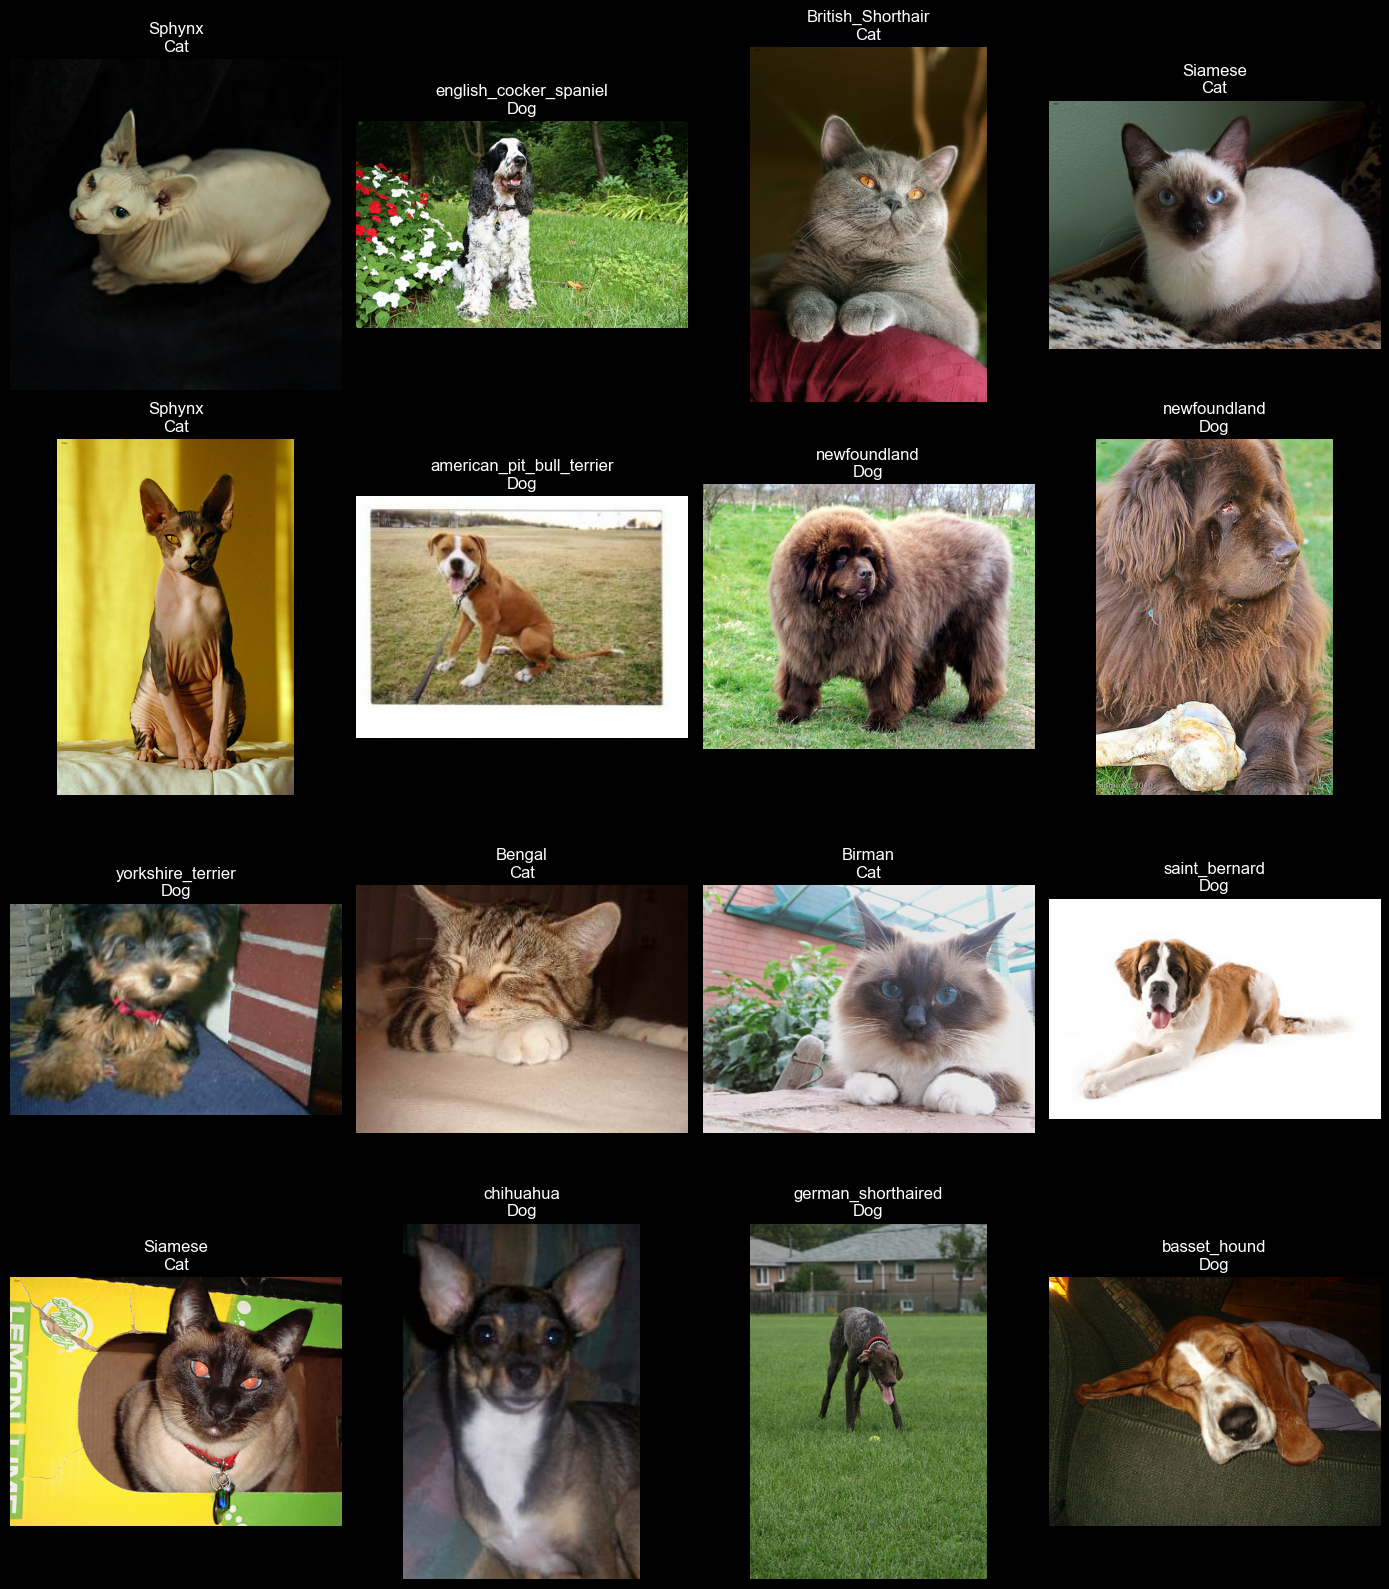

Saved sample image grid to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/figures/01_sample_pet_grid.png


In [22]:
#
# Display Sample Images
#

def show_sample_images(dataset, breed_names, species_names, num_images=16):
    """
    Display a grid of sample images from a TensorFlow Dataset.

    Parameters
    ----------
    dataset : tf.data.Dataset
        Dataset split containing image examples.

    breed_names : list
        Human-readable breed label names.

    species_names : list
        Human-readable species label names.

    num_images : int
        Number of images to display.
    """

    # Use four columns for a readable image grid.
    cols = 4
    rows = int(np.ceil(num_images / cols))

    plt.figure(figsize=(14, 4 * rows))

    # Take a small number of examples from the dataset for visualization.
    for i, example in enumerate(dataset.take(num_images)):

        # Extract image and labels from the TensorFlow example.
        image = example["image"].numpy()
        label_index = int(example["label"].numpy())
        species_index = int(example["species"].numpy())

        # Convert numeric labels into readable names.
        breed = breed_names[label_index]
        species = species_names[species_index]

        # Plot image in the grid.
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.title(f"{breed}\n{species}")
        plt.axis("off")

    plt.tight_layout()


# Generate and save the sample image grid.
show_sample_images(
    dataset=ds_train,
    breed_names=breed_names,
    species_names=species_names,
    num_images=16
)

sample_grid_path = FIGURE_DIR / "01_sample_pet_grid.png"
plt.savefig(sample_grid_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved sample image grid to: {sample_grid_path}")

## 10. Raw Image Size Inspection

The raw Oxford-IIIT Pet images are not all the same size. CNN models require a consistent input shape, so later modeling notebooks will resize each image to a standard size before training or inference.

For this project, we plan to use:

- image size: `224 x 224`,
- color channels: RGB,
- batch size: `32`.

The `224 x 224` image size is compatible with common pretrained CNN architectures such as MobileNetV2, ResNet50, and EfficientNetB0.

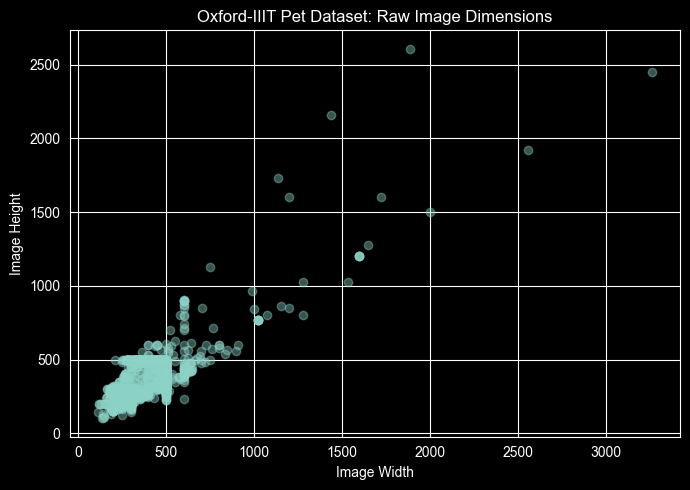

Saved raw image dimensions plot to: /Users/charlesleemuddjr/2021PythonProjects/adsp_32023_ACV/advanced_cv_pet_breed_project/outputs/figures/01_raw_image_dimensions.png


In [23]:
#
# Plot Raw Image Dimensions
#

# Create a scatter plot of original image width and height.
plt.figure(figsize=(7, 5))

plt.scatter(
    metadata_df["width"],
    metadata_df["height"],
    alpha=0.4
)

plt.xlabel("Image Width")
plt.ylabel("Image Height")
plt.title("Oxford-IIIT Pet Dataset: Raw Image Dimensions")

plt.tight_layout()

# Save the figure before displaying it.
image_dimensions_path = FIGURE_DIR / "01_raw_image_dimensions.png"
plt.savefig(image_dimensions_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved raw image dimensions plot to: {image_dimensions_path}")

In [24]:
#
# Summarize Image Dimensions
#

# Display descriptive statistics for raw image height, width, and channels.
metadata_df[["height", "width", "channels"]].describe()

,height,width,channels
count,7349.000000,7349.000000,7349.0
mean,391.387264,437.237447,3.0
std,109.394560,115.775876,0.0
min,103.000000,114.000000,3.0
25%,333.000000,337.000000,3.0
50%,375.000000,500.000000,3.0
75%,500.000000,500.000000,3.0
max,2606.000000,3264.000000,3.0


## 11. Preprocessing Decisions for Later Notebooks

Based on the dataset inspection, later modeling notebooks will use the following preprocessing decisions:

1. Resize all images to `224 x 224`.
2. Use RGB color images.
3. Use the breed label as the prediction target.
4. Use all 37 pet breed classes.
5. Use the official TensorFlow Datasets train/test split.
6. Create a validation split from the training data during model development.
7. Use image augmentation during training for the CNN and transfer learning models.
8. Save trained models, result tables, and figures to organized output folders.

These decisions keep the project consistent across baseline classification, transfer learning, and similarity-based image retrieval.

## 12. Notebook Summary

This notebook loaded and inspected the Oxford-IIIT Pet Dataset. The project will use the full 37-class pet breed classification task, including both cat and dog breeds.

The dataset contains:

- 3,680 training images,
- 3,669 test images,
- 7,349 total images,
- 37 breed classes,
- 2 species categories.

Key outputs saved by this notebook include:

- dataset metadata,
- dataset summary,
- class counts,
- species counts,
- class distribution plot,
- species distribution plot,
- sample image grid,
- raw image dimension plot.

The next notebook will build a baseline CNN classifier trained from scratch. This baseline model will provide a comparison point for later transfer learning models.

## 13. Final Notebook Check

Notebook 01 successfully loaded and inspected the Oxford-IIIT Pet Dataset. The saved outputs from this notebook will support the final report, presentation, and later modeling notebooks.

The most important decisions from this notebook are:

1. The project will use the full 37-class pet breed classification task.
2. The project will include both cat and dog breeds because the Oxford-IIIT Pet Dataset contains both.
3. Images will be resized to 224 x 224 for CNN and transfer learning models.
4. The official TensorFlow Datasets train and test splits will be used.
5. A validation split will be created from the training data in later notebooks.
6. Exploratory figures and metadata tables have been saved for reuse.

The next notebook will build a baseline CNN classifier trained from scratch. This baseline will provide a comparison point for the later transfer learning model.